# -- Notebook 03: Visualisations --

**Summary of the notebook:**

* Basic EDA - investigating the following broad categories regarding collisions: 
    * WHERE do they happen? E.g., what types of areas (urban vs rural), weather conditions
    * WHEN do they happen? E.g., what time of day do they happen
    * WHO is involved? E.g., age groups of drivers, sex of drivers
    * WHAT is involved? E.g., different types of vehicles involved 
* These trends will be compared across time 

In [1]:
# Necessary libraries: 

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from plotly.subplots import make_subplots
import plotly.graph_objects as go
from pathlib import Path



c:\Users\abhik\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\abhik\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Base path - edit as necessary:
base_path = Path(r"C:/Users/abhik/OneDrive/Desktop/WISE")
viz_path = Path(r"C:/Users/abhik/OneDrive/Desktop/WISE/Data/Dashboard/Visualisations")

In [3]:
# Loading dataset: 

train_df_path = base_path / "Data" / "Processed" / "train_df.csv"
train_df = pd.read_csv(train_df_path)

test_df_path = base_path / "Data" / "Processed" / "test_df.csv"
test_df = pd.read_csv(test_df_path)

X_train_path = base_path / "Data" / "Processed" / "X_train.csv"
X_train = pd.read_csv(X_train_path )

X_test_path = base_path / "Data" / "Processed" / "X_test.csv"
X_test = pd.read_csv(X_test_path )

y_train_path = base_path / "Data" / "Processed" / "y_train.csv"
y_train = pd.read_csv(y_train_path )

y_test_path = base_path / "Data" / "Processed" / "y_test.csv"
y_test = pd.read_csv(y_test_path )

In [4]:
# For the sake of visualisation, I no longer need to split the dataset into X/y anymore
# I therefore merge the existing datasets back

data_comb = pd.concat([train_df, test_df])
data_comb = data_comb.reset_index(drop=True)

In [5]:
data_comb['collision_severity'].head()

0    3
1    3
2    2
3    3
4    3
Name: collision_severity, dtype: int64

**EDA:**

*Getting summary statistics of all the different variables:*

In [6]:
# Relevant variables: 

relevant_vars = ['collision_ref_no', 'collision_year', 'collision_severity', 
                 'location_easting_osgr', 'location_northing_osgr', 'longitude', 'latitude', 'urban_or_rural_area',
              'day_of_week', 'time', 'local_authority_district','first_road_class', 
              'road_type', 'speed_limit','vehicle_type', 'vehicle_left_hand_drive' , 
              'sex_of_driver', 'age_of_driver', 'age_band_of_driver', 'driver_imd_decile' , 'engine_capacity_cc', 
              'propulsion_code', 'age_of_vehicle' , 'generic_make_model', 'lsoa_of_driver',
              'journey_purpose_of_driver_historic' , 'age_of_casualty', 'age_band_of_casualty', 'sex_of_casualty', 
              'casualty_type']

In [7]:
data_comb = data_comb[relevant_vars]

In [8]:
data_comb.describe().round(2)

,collision_ref_no,collision_year,collision_severity,location_easting_osgr,location_northing_osgr,longitude,latitude,urban_or_rural_area,day_of_week,time,...,engine_capacity_cc,propulsion_code,age_of_vehicle,generic_make_model,lsoa_of_driver,journey_purpose_of_driver_historic,age_of_casualty,age_band_of_casualty,sex_of_casualty,casualty_type
count,1221287.00,1221287.00,1221287.00,1221287.00,1221287.00,1221287.00,1221287.00,1221287.00,1221287.00,1221287.00,...,1221287.00,1221287.00,1221287.00,1221287.00,1221287.00,1221287.00,1221287.00,1221287.00,1221287.00,1221287.00
mean,165656.81,2022.04,2.73,453959.52,277196.56,-1.23,52.38,1.37,4.14,856.51,...,1771.21,1.66,8.43,423.65,16979.98,4.88,38.03,6.53,1.38,7.71
std,130959.79,1.39,0.48,93378.83,146484.65,1.37,1.32,0.48,1.96,304.18,...,1372.08,1.49,5.14,303.55,8985.80,1.83,18.39,2.15,0.49,8.61
min,-1.00,2020.00,1.00,65947.00,10211.00,-7.50,49.91,1.00,1.00,0.00,...,6.00,1.00,0.00,-1.00,-1.00,1.00,0.00,1.00,1.00,0.00
25%,29937.50,2021.00,3.00,391502.00,175018.00,-2.13,51.46,1.00,2.00,650.00,...,1388.00,1.00,5.00,174.00,10289.00,5.00,24.00,5.00,1.00,3.00
50%,161347.00,2022.00,3.00,458735.00,222832.00,-1.13,51.89,1.00,4.00,900.00,...,1596.00,1.00,8.00,291.00,18908.00,6.00,35.00,6.00,1.00,9.00
75%,279302.00,2023.00,3.00,529257.00,384837.00,-0.14,53.36,2.00,6.00,1075.00,...,1968.00,2.00,11.00,717.00,22812.00,6.00,51.00,8.00,2.00,9.00
max,402234.00,2024.00,3.00,655345.00,1184351.00,1.76,60.54,3.00,7.00,1439.00,...,48000.00,12.00,123.00,994.00,34647.00,6.00,101.00,11.00,9.00,99.00


**Distribution of collision severity:**


In [9]:
# Collision severity map: 
sev_map = {1: "01: Fatal", 2: "02: Serious",  3: "03: Slight"}

# Value counts for each level of severity of collision: 
sev_year = pd.crosstab(data_comb["collision_year"], data_comb["collision_severity"].map(sev_map), margins = False, margins_name = "Total")
sev_year 


collision_severity,01: Fatal,02: Serious,03: Slight
collision_year,,,
2020,4231,44828,171376
2021,4668,53071,188575
2022,5129,59465,193606
2023,5151,59568,188180
2024,4985,60102,178352


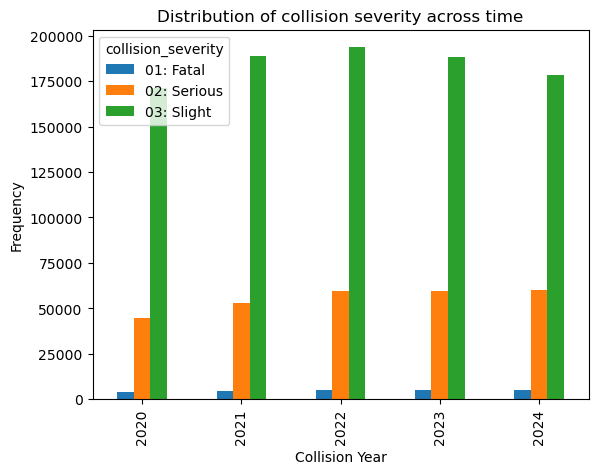

In [10]:
sev_year.plot(kind = 'bar')
plt.ylabel('Frequency')
plt.xlabel('Collision Year')
plt.title('Distribution of collision severity across time')

fig1_path = viz_path / "severity_distribution_across_time.png"
plt.savefig(fig1_path, dpi=300, bbox_inches="tight")

plt.show()

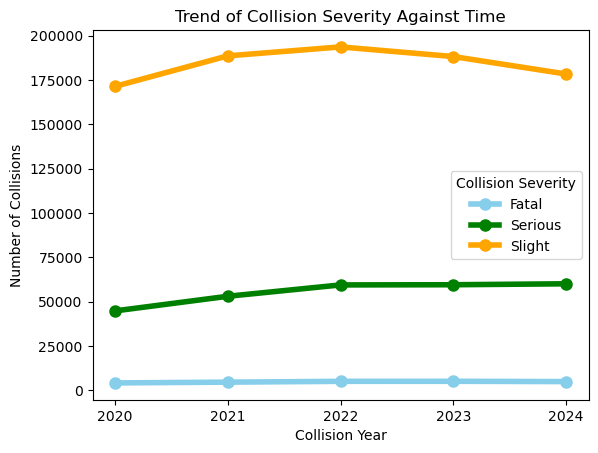

In [11]:
# Line plots:

# Severity = 1
severity_1_df = data_comb[data_comb["collision_severity"] == 1]
sev_1_counts = severity_1_df["collision_year"].value_counts().sort_index()
plt.plot(sev_1_counts.index, sev_1_counts.values, marker='o', color='skyblue', linewidth=4, markersize=8,label = 'Fatal'
)

# Severity = 2
severity_2_df = data_comb[data_comb["collision_severity"] == 2]
sev_2_counts = severity_2_df["collision_year"].value_counts().sort_index()
plt.plot(sev_2_counts.index, sev_2_counts.values, marker='o', color='green', linewidth=4, markersize=8, label = 'Serious'
)

# Severity = 3
severity_3_df = data_comb[data_comb["collision_severity"] == 3]
sev_3_counts = severity_3_df["collision_year"].value_counts().sort_index()
plt.plot(sev_3_counts.index, sev_3_counts.values, marker='o', color='orange', linewidth=4, markersize=8,label = 'Slight'
)

plt.xlabel("Collision Year")
plt.ylabel("Number of Collisions")
plt.title("Trend of Collision Severity Against Time")
plt.xticks(sev_year.index)
plt.legend(title="Collision Severity", loc="best")

fig2_path = viz_path / "severity_trends_across_time.png"
plt.savefig(fig2_path, dpi=300, bbox_inches="tight")

plt.show()

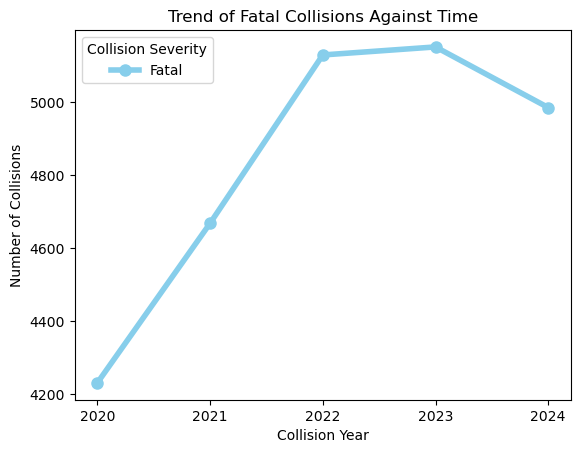

In [12]:
# Plot of fatal collisions across time: 

plt.plot(sev_1_counts.index, sev_1_counts.values, marker='o', color='skyblue', linewidth=4, markersize=8,label = 'Fatal')

plt.xlabel("Collision Year")
plt.ylabel("Number of Collisions")
plt.title("Trend of Fatal Collisions Against Time")
plt.xticks(sev_year.index)
plt.legend(title="Collision Severity", loc="best")

fig3_path = viz_path / "fatal_collisions_across_time.png"
plt.savefig(fig3_path, dpi=300, bbox_inches="tight")

plt.show()

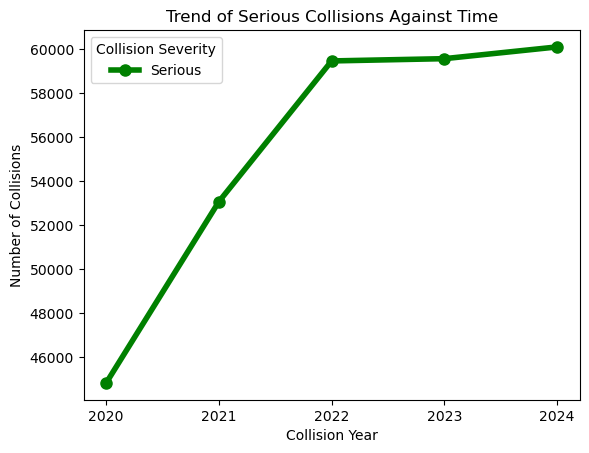

In [13]:
# Plot of serious collisions across time: 

plt.plot(sev_2_counts.index, sev_2_counts.values, marker='o', color='green', linewidth=4, markersize=8, label = 'Serious')

plt.xlabel("Collision Year")
plt.ylabel("Number of Collisions")
plt.title("Trend of Serious Collisions Against Time")
plt.xticks(sev_year.index)
plt.legend(title="Collision Severity", loc="best")

fig4_path = viz_path / "serious_collisions_across_time.png"
plt.savefig(fig4_path, dpi=300, bbox_inches="tight")

plt.show()

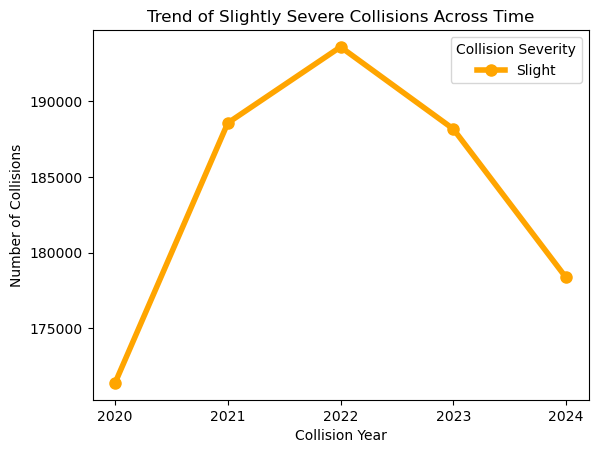

In [14]:
# Plot of slighly severe collisions across time: 

plt.plot(sev_3_counts.index, sev_3_counts.values, marker='o', color='orange', linewidth=4, markersize=8,label = 'Slight')

plt.xlabel("Collision Year")
plt.ylabel("Number of Collisions")
plt.title("Trend of Slightly Severe Collisions Across Time")
plt.xticks(sev_year.index)
plt.legend(title="Collision Severity", loc="best")

fig5_path = viz_path / "slight_collisions_across_time.png"
plt.savefig(fig5_path, dpi=300, bbox_inches="tight")


plt.show()

We see that most collisions are only slightly severe. Across time, we see that the number of slightly severe collisions is reducing, whilst the number of serious collisions is increasing. This could signal either a shift to more riskier driving, or potentially a return to pre-COVID trends.

**WHERE do collisions happen?**

*Investigating different area types: urban vs rural:*

In [15]:
# Mapping dictionary to provide labels for the different area types: 
area_map = {1: 'Urban', 2: 'Rural'}

# Mapping disctionary for different severity values: 
sev_map = {1: "Fatal", 2: "Serious",  3: "Slight"}

# Table of raw counts: 
severity_ruralurban = pd.crosstab(index = data_comb["collision_year"], columns = [data_comb["urban_or_rural_area"].map(area_map), data_comb["collision_severity"].map(sev_map)], margins = False, margins_name = "Total")
severity_ruralurban

# Whilst this table of raw counts is useful, it can be improved
# The % of all collisions that are a certain severity level within each type of area can be a more useful visualisation


urban_or_rural_area Rural                Urban                
collision_severity  Fatal Serious Slight Fatal Serious  Slight
collision_year                                                
2020                 2867   20412  55463  1364   24412  115883
2021                 3252   24016  62356  1415   29038  126194
2022                 3692   27291  65366  1437   32165  128206
2023                 3622   27563  64948  1529   32002  123224
2024                 3615   27738  62713  1370   32364  115627

In [16]:
# Table of percentages: 

severity_ruralurban_pct = pd.crosstab(index = data_comb["collision_year"], columns = [data_comb["urban_or_rural_area"].map(area_map), data_comb["collision_severity"].map(sev_map)], normalize = "index")*100
severity_ruralurban_pct


urban_or_rural_area     Rural                           Urban             \
collision_severity      Fatal    Serious     Slight     Fatal    Serious   
collision_year                                                             
2020                 1.300811   9.261301  25.164586  0.618872  11.076175   
2021                 1.320497   9.751859  25.320074  0.574570  11.791076   
2022                 1.430137  10.571474  25.320251  0.556638  12.459472   
2023                 1.432255  10.899291  25.682516  0.604615  12.654614   
2024                 1.485045  11.394792  25.762549  0.562797  13.295156   

urban_or_rural_area             
collision_severity      Slight  
collision_year                  
2020                 52.578255  
2021                 51.241925  
2022                 49.662027  
2023                 48.726709  
2024                 47.499661

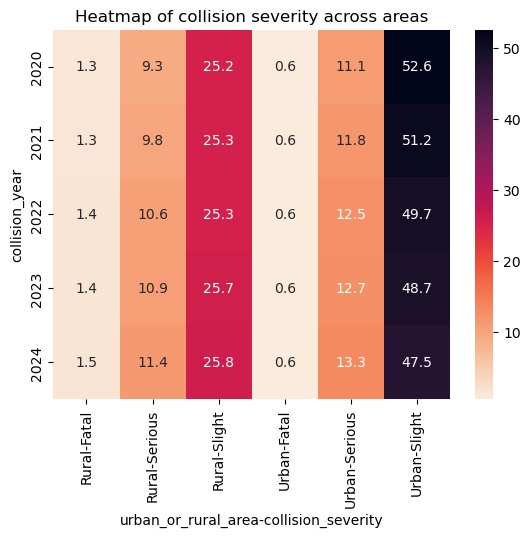

In [17]:
# Heatmap of collision severities across areas: 

sns.heatmap(severity_ruralurban_pct, annot = True, cbar = True, fmt = ".1f", cmap = "rocket_r")
plt.title("Heatmap of collision severity across areas")

fig6_path = viz_path / "severity_rural_urban_heatmap.png"
plt.savefig(fig6_path, dpi=300, bbox_inches="tight")

plt.show()

We see that the most common severity level of collisions across urban and rural areas is "slight". It is also interesting to see that a greater proportion of rural collisions are fatal - however this could just be because of fewer collisions in rural areas in general. 

**WHO is involved in different collisions?**

*Most common age of driver across different collision types*

In [18]:
# Creating mapping for age band of driver: 
age_map = {1: "0 - 05", 2: "06 - 10", 3: "11 - 15", 4: "16 - 20",
           5: "21 - 25", 6: "26 - 35", 7: "36 - 45",
           8: "46 - 55", 9: "56 - 65", 10: "66 - 75", 11: "Over 75"}


train_2020 = data_comb[data_comb["collision_year"] == 2020]
train_2021 = data_comb[data_comb["collision_year"] == 2021]
train_2022 = data_comb[data_comb["collision_year"] == 2022]
train_2023 = data_comb[data_comb["collision_year"] == 2023]
train_2024 = data_comb[data_comb["collision_year"] == 2024]


# Two-way table for 2020: 
severity_ageband_2020 = pd.crosstab(train_2020["collision_severity"].map(sev_map), train_2020["age_band_of_driver"].map(age_map), normalize = "index")*100

# Two-way table for 2021: 
severity_ageband_2021 = pd.crosstab(train_2021["collision_severity"].map(sev_map), train_2021["age_band_of_driver"].map(age_map), normalize = "index")*100

# Two-way table for 2022: 
severity_ageband_2022 = pd.crosstab(train_2022["collision_severity"].map(sev_map), train_2022["age_band_of_driver"].map(age_map), normalize = "index")*100

# Two-way table for 2023: 
severity_ageband_2023 = pd.crosstab(train_2023["collision_severity"].map(sev_map), train_2023["age_band_of_driver"].map(age_map), normalize = "index")*100

# Two-way tabel for 2024: 
severity_ageband_2024 = pd.crosstab(train_2024["collision_severity"].map(sev_map), train_2024["age_band_of_driver"].map(age_map), normalize = "index")*100



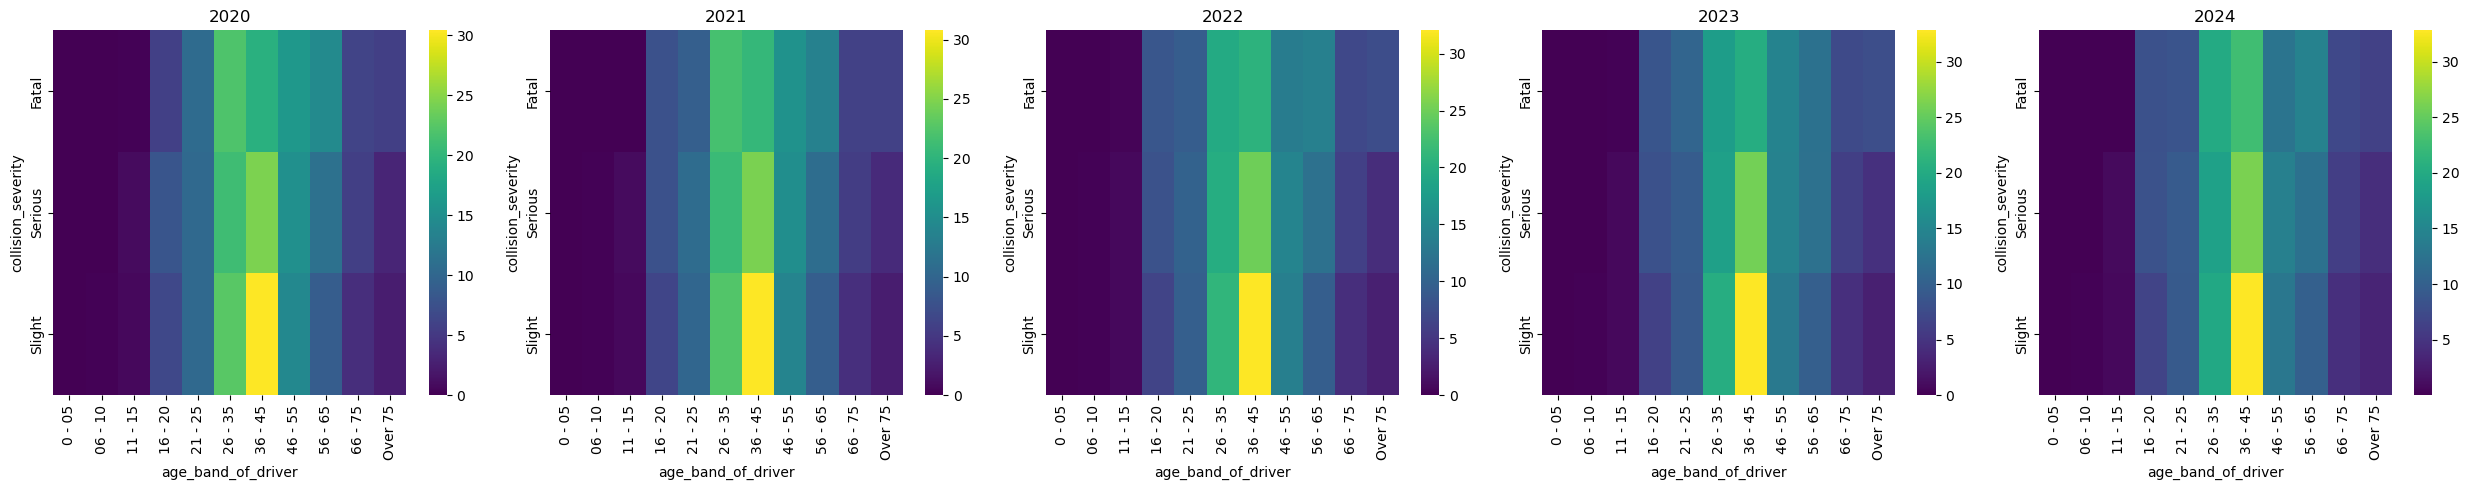

In [19]:
# Heatmaps: 

fig, ax = plt.subplots(ncols=5, nrows= 1, figsize = (25,5))

sns.heatmap(severity_ageband_2020, annot = False, cbar = True, fmt = ".1f", cmap = "viridis", ax = ax[0])
sns.heatmap(severity_ageband_2021, annot = False, cbar = True, fmt = ".1f", cmap = "viridis", ax = ax[1])
sns.heatmap(severity_ageband_2022, annot = False, cbar = True, fmt = ".1f", cmap = "viridis", ax = ax[2])
sns.heatmap(severity_ageband_2023, annot = False, cbar = True, fmt = ".1f", cmap = "viridis", ax = ax[3])
sns.heatmap(severity_ageband_2024, annot = False, cbar = True, fmt = ".1f", cmap = "viridis", ax = ax[4])

ax[0].set_title("2020")
ax[1].set_title("2021")
ax[2].set_title("2022")
ax[3].set_title("2023")
ax[4].set_title("2024")

fig7_path = viz_path / "severity_driver_age_heatmap.png"
plt.savefig(fig7_path, dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

This shows us the proportion of accidents caused by a certain age group for each severity level for each age group. Here, we see that older drivers are responsible for a lower proportion of accidents in general, as this shows that fatal accidents are mostly caused by the 26 - 45 age block. 

Interestingly, we see that across time, the "blame" of fatal accidents caused is shifting slowly to a younger population - we see that the proportion of fatal accidents is increasingly shifting to the 21-25 age group now, whilst the proportion of datal accidents caused by the 26-35 and 36-45 age group decreases across the years. 

*Investigating age of victims in collisions:*

In [20]:
# Two-way table:

# Two-way table for 2020: 
severity_ageband_c_2020 = pd.crosstab(train_2020["collision_severity"].map(sev_map), train_2020["age_band_of_casualty"].map(age_map), normalize = "index")*100

# Two-way table for 2021: 
severity_ageband_c_2021 = pd.crosstab(train_2021["collision_severity"].map(sev_map), train_2021["age_band_of_casualty"].map(age_map), normalize = "index")*100

# Two-way table for 2022: 
severity_ageband_c_2022 = pd.crosstab(train_2022["collision_severity"].map(sev_map), train_2022["age_band_of_casualty"].map(age_map), normalize = "index")*100

# Two-way table for 2023: 
severity_ageband_c_2023 = pd.crosstab(train_2023["collision_severity"].map(sev_map), train_2023["age_band_of_casualty"].map(age_map), normalize = "index")*100

# Two-way table for 2024: 
severity_ageband_c_2024 = pd.crosstab(train_2024["collision_severity"].map(sev_map), train_2024["age_band_of_casualty"].map(age_map), normalize = "index")*100



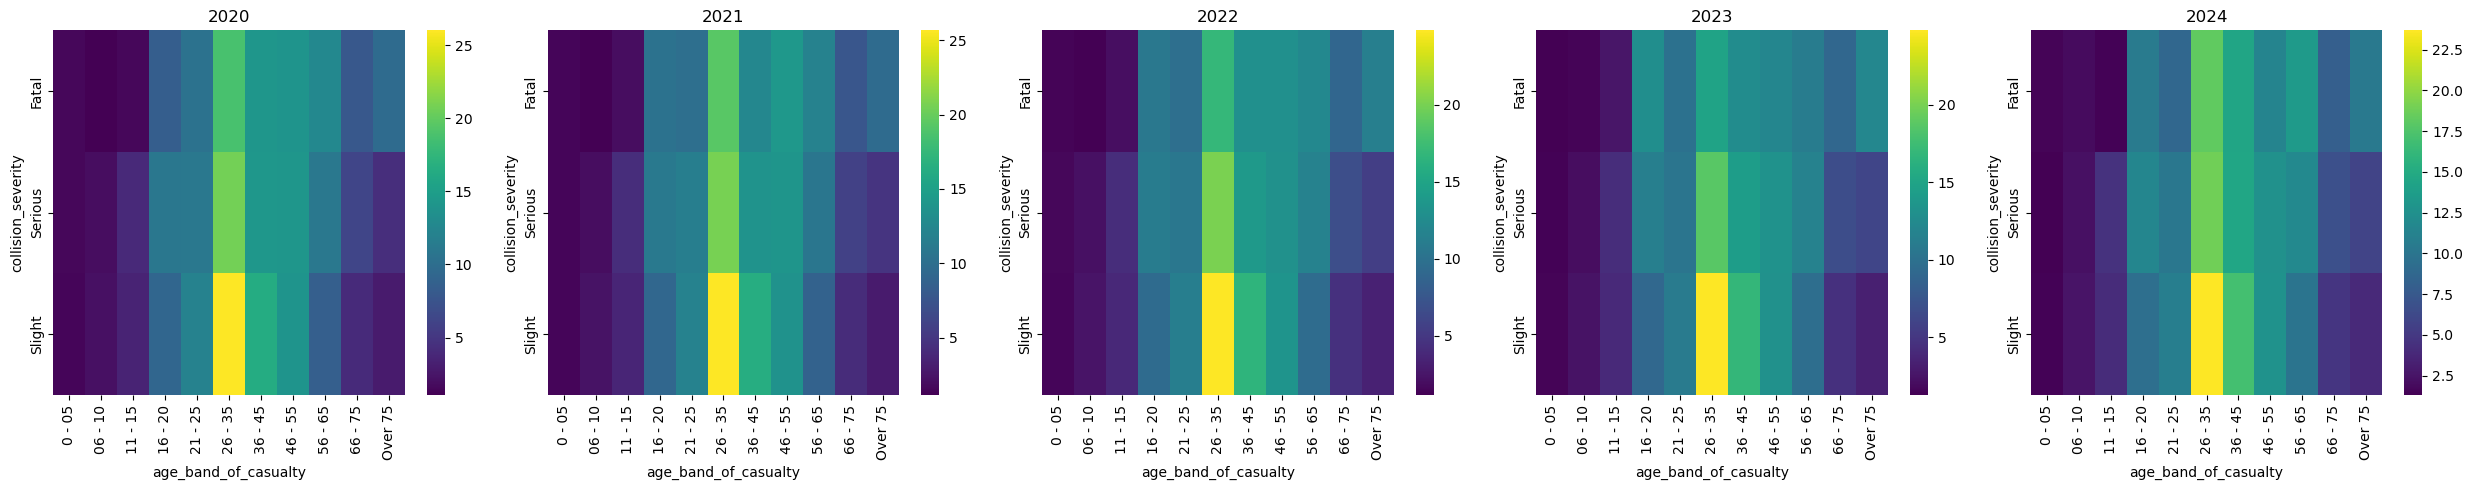

In [21]:
# Heatmap: 
fig, ax = plt.subplots(ncols=5, nrows=1, figsize = (25,5))

sns.heatmap(severity_ageband_c_2020, annot = False, cbar = True, fmt = ".1f", cmap = "viridis", ax = ax[0])
sns.heatmap(severity_ageband_c_2021, annot = False, cbar = True, fmt = ".1f", cmap = "viridis", ax = ax[1])
sns.heatmap(severity_ageband_c_2022, annot = False, cbar = True, fmt = ".1f", cmap = "viridis", ax = ax[2])
sns.heatmap(severity_ageband_c_2023, annot = False, cbar = True, fmt = ".1f", cmap = "viridis", ax = ax[3])
sns.heatmap(severity_ageband_c_2024, annot = False, cbar = True, fmt = ".1f", cmap = "viridis", ax = ax[4])

ax[0].set_title("2020")
ax[1].set_title("2021")
ax[2].set_title("2022")
ax[3].set_title("2023")
ax[4].set_title("2024")

fig8_path = viz_path / "severity_casualty_age_heatmap.png"
plt.savefig(fig8_path, dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

*Investigating the deprivation of drivers involved in collisions:*

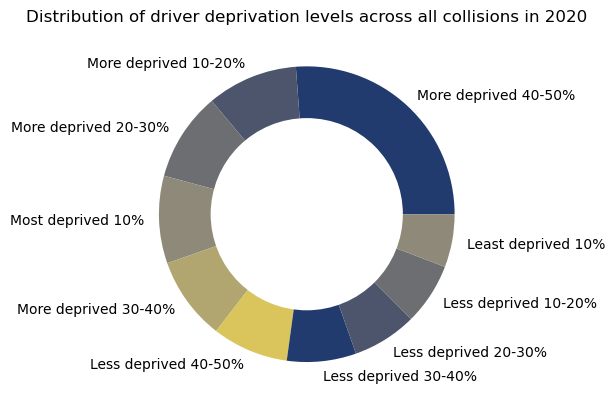

In [22]:
# Pie chart of deprivation levels of drivers: 

deprivation_map = {1: "Most deprived 10%", 2: "More deprived 10-20%", 3: "More deprived 20-30%", 4:	"More deprived 30-40%", 5:	"More deprived 40-50%", 6:	"Less deprived 40-50%", 7:	"Less deprived 30-40%", 8:	"Less deprived 20-30%", 9:	"Less deprived 10-20%",  10:	"Least deprived 10%"}

deprivation_counts_2020 = train_2020['driver_imd_decile'].value_counts()
plt.pie(deprivation_counts_2020, labels = deprivation_counts_2020.index.map(deprivation_map), colors = sns.color_palette('cividis'))

hole = plt.Circle((0,0), 0.65, facecolor = 'white')
plt.gcf().gca().add_artist(hole)

plt.title("Distribution of driver deprivation levels across all collisions in 2020")

fig9a_path = viz_path / "severity_deprivation_pie_2020.png"
plt.savefig(fig9a_path, dpi=300, bbox_inches="tight")

plt.show()

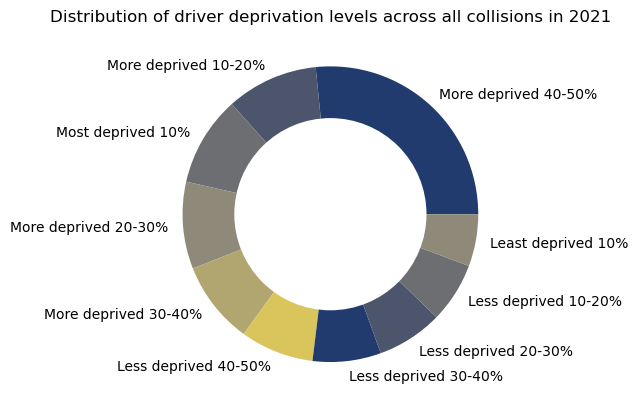

In [23]:
deprivation_counts_2021 = train_2021['driver_imd_decile'].value_counts()
plt.pie(deprivation_counts_2021, labels = deprivation_counts_2021.index.map(deprivation_map), colors = sns.color_palette('cividis'))
plt.title("Distribution of driver deprivation levels across all collisions in 2021")

hole = plt.Circle((0,0), 0.65, facecolor = 'white')
plt.gcf().gca().add_artist(hole)

fig9b_path = viz_path / "severity_deprivation_pie_2021.png"
plt.savefig(fig9b_path, dpi=300, bbox_inches="tight")

plt.show()

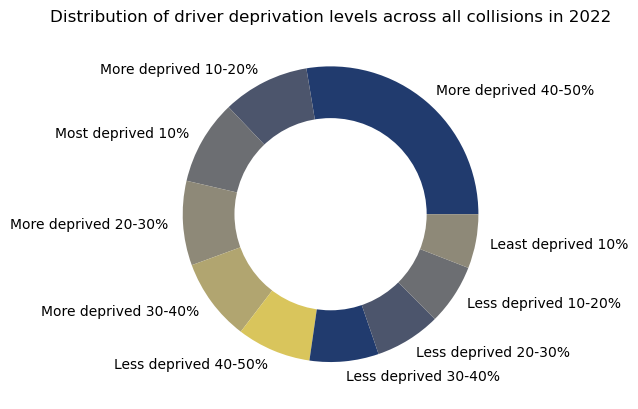

In [24]:
deprivation_counts_2022 = train_2022['driver_imd_decile'].value_counts()
plt.pie(deprivation_counts_2022, labels = deprivation_counts_2022.index.map(deprivation_map), colors = sns.color_palette('cividis'))
plt.title("Distribution of driver deprivation levels across all collisions in 2022")

hole = plt.Circle((0,0), 0.65, facecolor = 'white')
plt.gcf().gca().add_artist(hole)

fig9c_path = viz_path / "severity_deprivation_pie_2022.png"
plt.savefig(fig9c_path, dpi=300, bbox_inches="tight")

plt.show()

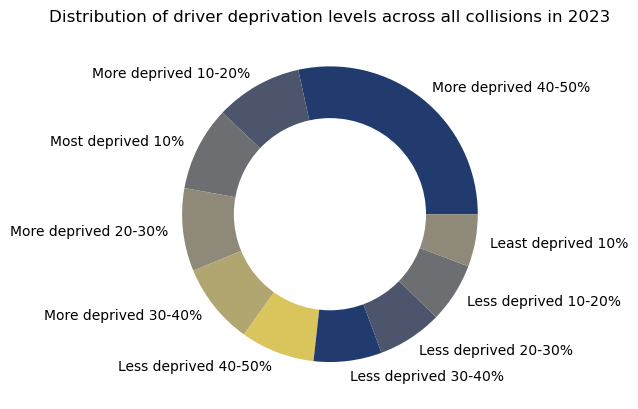

In [25]:
deprivation_counts_2023 = train_2023['driver_imd_decile'].value_counts()
plt.pie(deprivation_counts_2023, labels = deprivation_counts_2023.index.map(deprivation_map), colors = sns.color_palette('cividis'))
plt.title("Distribution of driver deprivation levels across all collisions in 2023")

hole = plt.Circle((0,0), 0.65, facecolor = 'white')
plt.gcf().gca().add_artist(hole)

fig9d_path = viz_path / "severity_deprivation_pie_2023.png"
plt.savefig(fig9d_path, dpi=300, bbox_inches="tight")


plt.show()

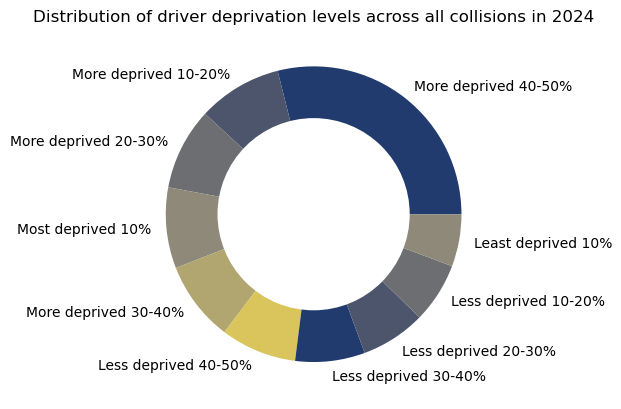

In [26]:
deprivation_counts_2024 = train_2024['driver_imd_decile'].value_counts()
plt.pie(deprivation_counts_2024, labels = deprivation_counts_2024.index.map(deprivation_map), colors = sns.color_palette('cividis'))
plt.title("Distribution of driver deprivation levels across all collisions in 2024")

hole = plt.Circle((0,0), 0.65, facecolor = 'white')
plt.gcf().gca().add_artist(hole)

fig9e_path = viz_path / "severity_deprivation_pie_2024.png"
plt.savefig(fig9e_path, dpi=300, bbox_inches="tight")

plt.show()

We see that the majority of collisions from 2020-2023 were caused by those in the 40th-50th percentile of deprivation. Intuitively, this makes sense because the most deprived individuals may not have sufficient amounts of money to own car or may be more careful when driving because they know they cannot afford to bear the costs of a collision. Likewise, the least deprived 10% cause a small proportion of collisions because....

*Investigating the sex of drivers involved in collisions:*

In [27]:
sex_map = {1: "Male", 2: "Female"}

sex_year = pd.crosstab(data_comb["collision_year"], data_comb["sex_of_driver"].map(sex_map), margins = False, margins_name = "Total")
sex_year 


sex_of_driver,Female,Male
collision_year,,
2020,57393,140691
2021,64834,155175
2022,69298,160266
2023,67513,155664
2024,64823,153972


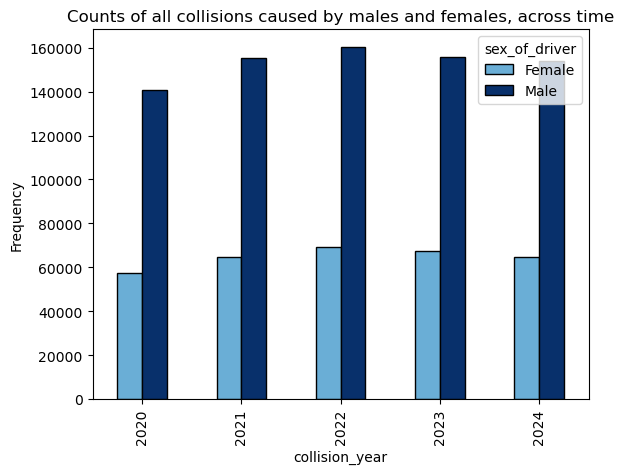

In [28]:

cmap = plt.colormaps['Blues']
bar_colors = cmap(np.linspace(0.5,1, 2))

sex_year.plot(kind = 'bar',width = 0.5, color = bar_colors, edgecolor = 'black')
plt.ylabel('Frequency')
plt.title("Counts of all collisions caused by males and females, across time")

fig10a_path = viz_path / "collision_sex.png"
plt.savefig(fig10a_path, dpi=300, bbox_inches="tight")

plt.show()

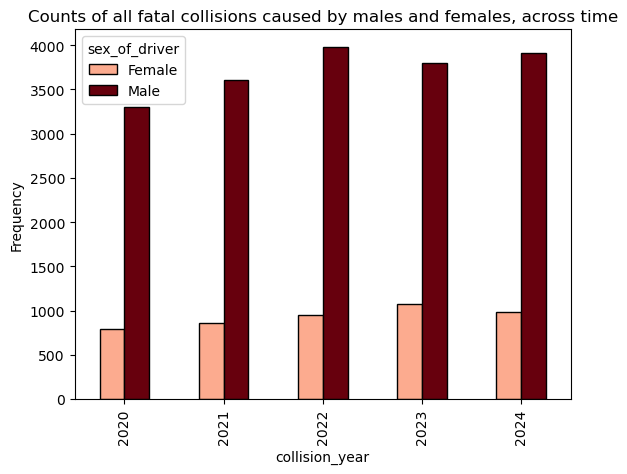

In [29]:
# Fatal collisions: 

sex_year_fatal = pd.crosstab(data_comb[data_comb["collision_severity"] == 1]["collision_year"], data_comb["sex_of_driver"].map(sex_map), margins = False, margins_name = "Total")

cmap = plt.colormaps['Reds']
bar_colors = cmap(np.linspace(0.3,1, 2))

sex_year_fatal.plot(kind = 'bar',width = 0.5, color = bar_colors, edgecolor = 'black')
plt.ylabel('Frequency')
plt.title("Counts of all fatal collisions caused by males and females, across time")

fig10b_path = viz_path / "collision_sex_fatal.png"
plt.savefig(fig10b_path, dpi=300, bbox_inches="tight")

plt.show()


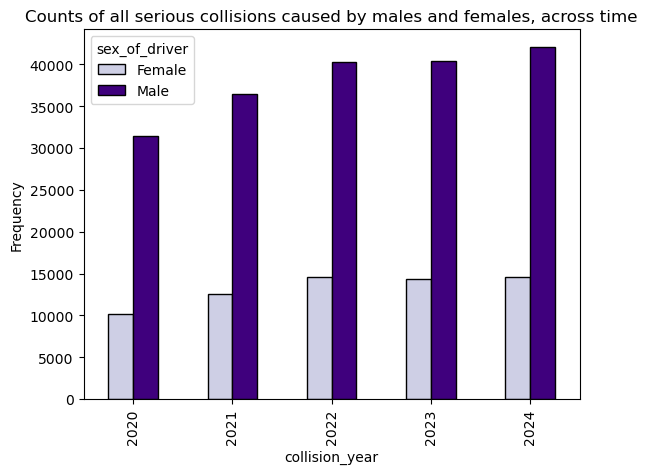

In [30]:
# Serious collisions: 

sex_year_serious = pd.crosstab(data_comb[data_comb["collision_severity"] == 2]["collision_year"], data_comb["sex_of_driver"].map(sex_map), margins = False, margins_name = "Total")

cmap = plt.colormaps['Purples']
bar_colors = cmap(np.linspace(0.3,1, 2))

sex_year_serious.plot(kind = 'bar',width = 0.5, color = bar_colors, edgecolor = 'black')
plt.ylabel('Frequency')
plt.title("Counts of all serious collisions caused by males and females, across time")

fig10c_path = viz_path / "collision_sex_serious.png"
plt.savefig(fig10c_path, dpi=300, bbox_inches="tight")

plt.show()

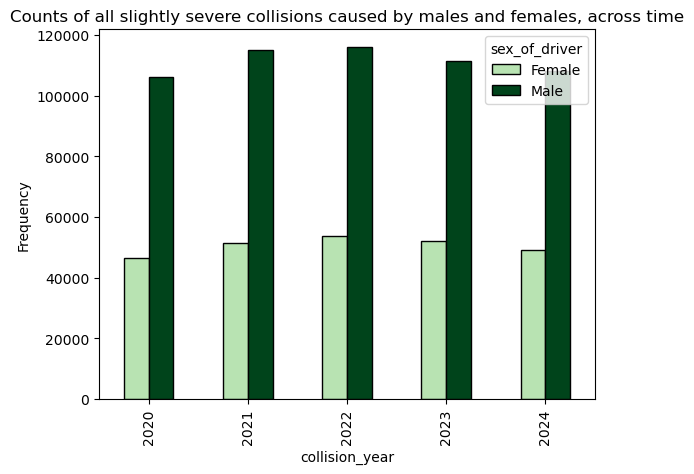

In [31]:
sex_year_slight = pd.crosstab(data_comb[data_comb["collision_severity"] == 3]["collision_year"], data_comb["sex_of_driver"].map(sex_map), margins = False, margins_name = "Total")

cmap = plt.colormaps['Greens']
bar_colors = cmap(np.linspace(0.3,1, 2))

sex_year_slight.plot(kind = 'bar',width = 0.5, color = bar_colors, edgecolor = 'black')
plt.ylabel('Frequency')
plt.title("Counts of all slightly severe collisions caused by males and females, across time")

fig10d_path = viz_path / "collision_sex_slightly.png"
plt.savefig(fig10d_path, dpi=300, bbox_inches="tight")

plt.show()

Here, we see that men have been responsible for more collisions in total from 2020 to 2024.    

**WHAT is involved?**

*Investigating vechicle types:*

In [32]:
# Map for type of vehicle propulsion: 

prop_map = {1:	"Petrol",
            2: 	"Heavy oil", 
            3:	"Electric", 
            4:	"Steam", 
            5:	"Gas", 
            6:	"Petrol/Gas (LPG)", 
            7:	"Gas/Bi-fuel", 
            8:	"Hybrid electric", 
            9:	"Gas Diesel", 
            10:	"New fuel technology", 
            11:	"Fuel cells", 
            12:	"Electric diesel"}

# Two-way table: 
severity_propulsion = pd.crosstab(data_comb["collision_severity"].map(sev_map), data_comb["propulsion_code"].map(prop_map), normalize = "index")*100
severity_propulsion

propulsion_code,Electric,Electric diesel,Fuel cells,Gas,Gas Diesel,Gas/Bi-fuel,Heavy oil,Hybrid electric,New fuel technology,Petrol,Petrol/Gas (LPG),Steam
collision_severity,,,,,,,,,,,,
Fatal,0.898030,0.202781,0.000000,0.070353,0.000000,0.091045,39.020857,2.925840,0.000000,56.786956,0.004138,0.000000
Serious,1.168449,0.186259,0.000000,0.025990,0.000361,0.040789,31.902221,3.666337,0.000361,62.999487,0.009385,0.000361
Slight,1.237815,0.183787,0.000652,0.022824,0.000435,0.047713,31.921042,4.368816,0.000326,62.211699,0.004673,0.000217


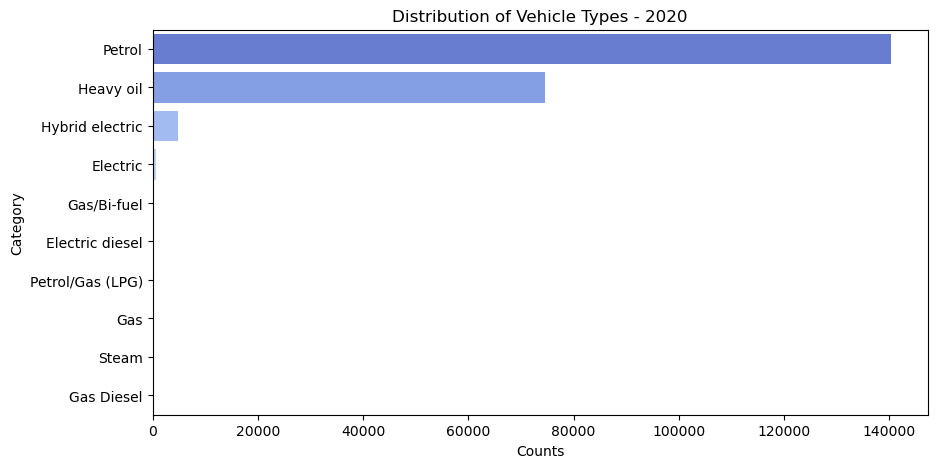

In [33]:
# Value counts for propulsion type: 
prop_counts_2020 = train_2020['propulsion_code'].value_counts()

# Bar chart: 
plt.figure(figsize=(10, 5))

sns.barplot(x=prop_counts_2020.values, y=prop_counts_2020.index.map(prop_map), palette = 'coolwarm')

plt.xlabel('Counts')
plt.ylabel('Category')
plt.title('Distribution of Vehicle Types - 2020')

fig11a_path = viz_path / "vehicle_type_dist_2020.png"
plt.savefig(fig11a_path, dpi=300, bbox_inches="tight")

plt.show()

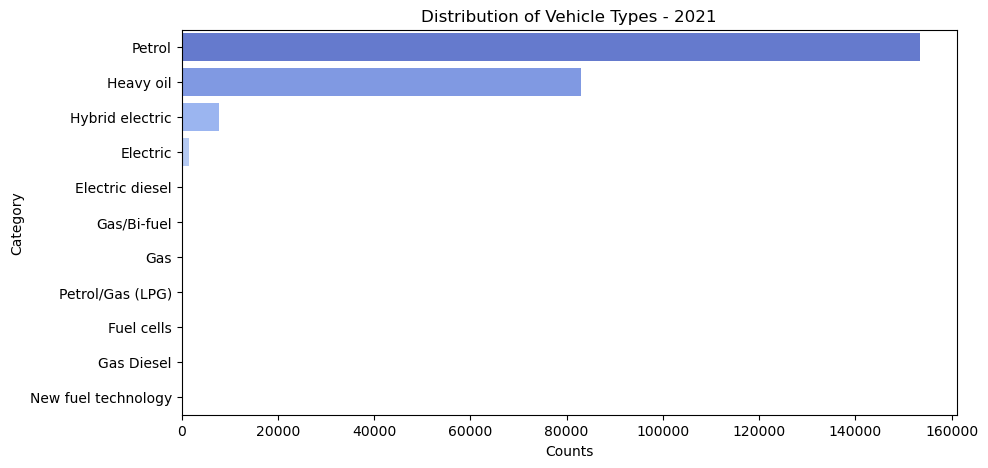

In [34]:
# Value counts for propulsion type: 
prop_counts_2021 = train_2021['propulsion_code'].value_counts()

# Bar chart: 
plt.figure(figsize=(10, 5))

sns.barplot(x=prop_counts_2021.values, y=prop_counts_2021.index.map(prop_map), palette = 'coolwarm')

plt.xlabel('Counts')
plt.ylabel('Category')
plt.title('Distribution of Vehicle Types - 2021')

fig11b_path = viz_path / "vehicle_type_dist_2021.png"
plt.savefig(fig11b_path, dpi=300, bbox_inches="tight")

plt.show()

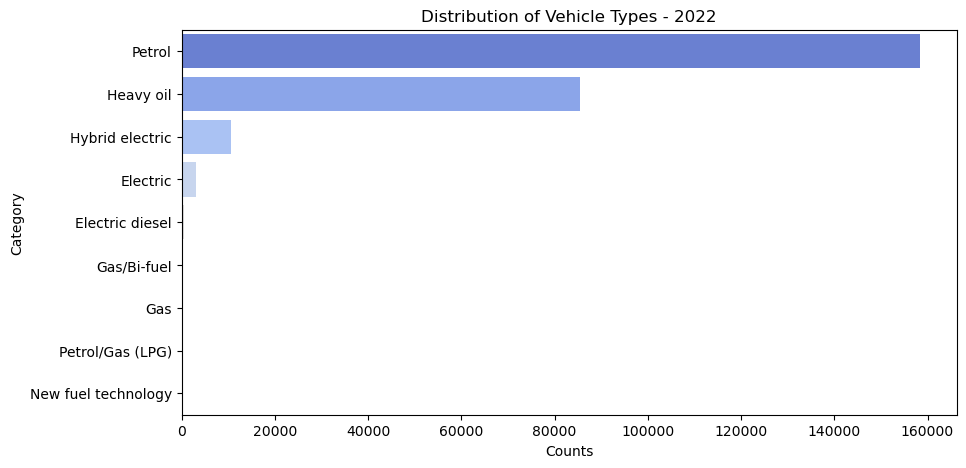

In [35]:
# Value counts for propulsion type: 
prop_counts_2022 = train_2022['propulsion_code'].value_counts()

# Bar chart: 
plt.figure(figsize=(10, 5))

sns.barplot(x=prop_counts_2022.values, y=prop_counts_2022.index.map(prop_map), palette = 'coolwarm')

plt.xlabel('Counts')
plt.ylabel('Category')
plt.title('Distribution of Vehicle Types - 2022')

fig11c_path = viz_path / "vehicle_type_dist_2022.png"
plt.savefig(fig11c_path, dpi=300, bbox_inches="tight")

plt.show()

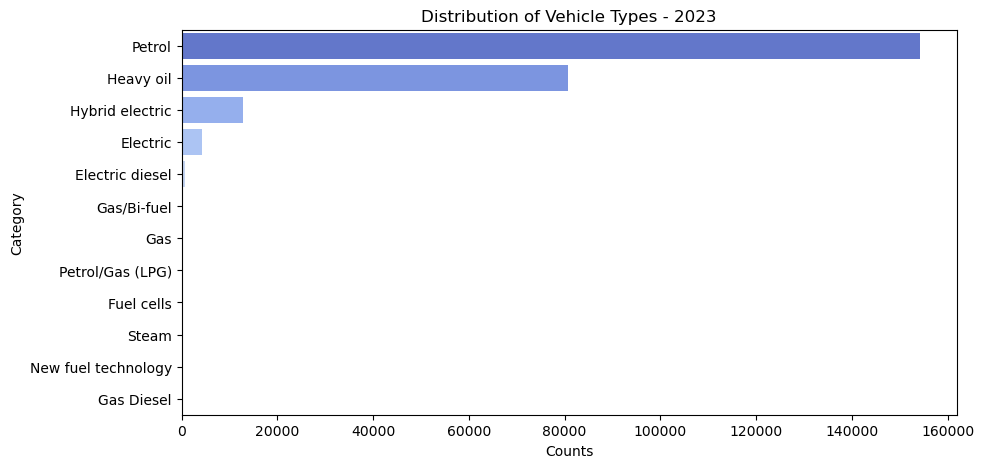

In [36]:
# Value counts for propulsion type: 
prop_counts_2023 = train_2023['propulsion_code'].value_counts()

# Bar chart: 
plt.figure(figsize=(10, 5))

sns.barplot(x=prop_counts_2023.values, y=prop_counts_2023.index.map(prop_map), palette = 'coolwarm')

plt.xlabel('Counts')
plt.ylabel('Category')
plt.title('Distribution of Vehicle Types - 2023')

fig11d_path = viz_path / "vehicle_type_dist_2023.png"
plt.savefig(fig11d_path, dpi=300, bbox_inches="tight")

plt.show()

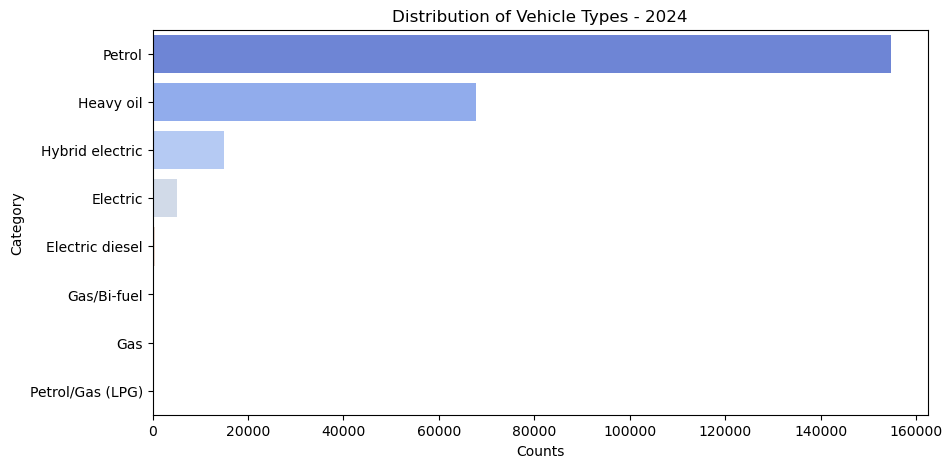

In [37]:
# Value counts for propulsion type: 
prop_counts_2024 = train_2024['propulsion_code'].value_counts()

# Bar chart: 
plt.figure(figsize=(10, 5))

sns.barplot(x=prop_counts_2024.values, y=prop_counts_2024.index.map(prop_map), palette = 'coolwarm')

plt.xlabel('Counts')
plt.ylabel('Category')
plt.title('Distribution of Vehicle Types - 2024')

fig11e_path = viz_path / "vehicle_type_dist_2024.png"
plt.savefig(fig11e_path, dpi=300, bbox_inches="tight")

plt.show()

*Distribution of age of vehicles for each type of colliision:*

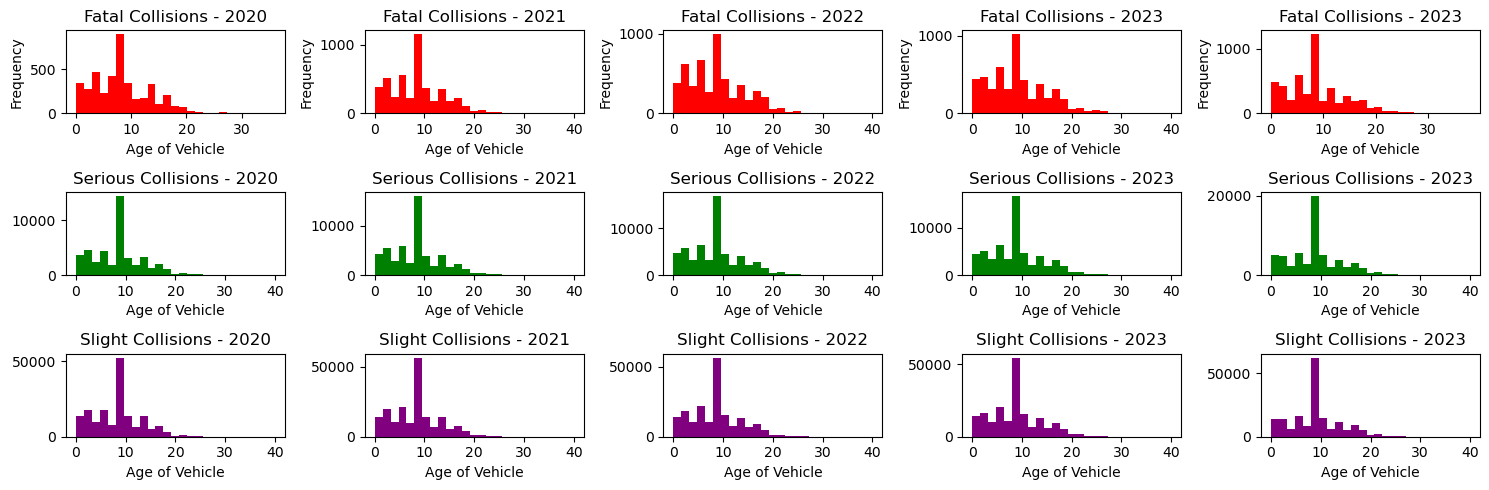

In [40]:
n_bins = 25

# Plots for 2020: 

fig, ax = plt.subplots(ncols=5, nrows=3, figsize=(15,5))
ax[0,0].hist(train_2020[(train_2020['age_of_vehicle'] <= 40) & (train_2020['collision_severity'] == 1)]['age_of_vehicle'],bins=n_bins,color='red')
ax[0,0].set_title("Fatal Collisions - 2020")
ax[0,0].set_xlabel("Age of Vehicle")
ax[0,0].set_ylabel("Frequency")

ax[1,0].hist(train_2020[(train_2020['age_of_vehicle'] <= 40) & (train_2020['collision_severity'] == 2)]['age_of_vehicle'],bins=n_bins,color='green')
ax[1,0].set_title("Serious Collisions - 2020")
ax[1,0].set_xlabel("Age of Vehicle")

ax[2,0].hist(train_2020[(train_2020['age_of_vehicle'] <= 40) & (train_2020['collision_severity'] == 3)]['age_of_vehicle'],bins=n_bins,color='purple')
ax[2,0].set_title("Slight Collisions - 2020")
ax[2,0].set_xlabel("Age of Vehicle")


# Plots for 2021: 

ax[0,1].hist(train_2021[(train_2021['age_of_vehicle'] <= 40) & (train_2021['collision_severity'] == 1)]['age_of_vehicle'],bins=n_bins,color='red')
ax[0,1].set_title("Fatal Collisions - 2021")
ax[0,1].set_xlabel("Age of Vehicle")
ax[0,1].set_ylabel("Frequency")

ax[1,1].hist(train_2021[(train_2021['age_of_vehicle'] <= 40) & (train_2021['collision_severity'] == 2)]['age_of_vehicle'],bins=n_bins,color='green')
ax[1,1].set_title("Serious Collisions - 2021")
ax[1,1].set_xlabel("Age of Vehicle")

ax[2,1].hist(train_2021[(train_2021['age_of_vehicle'] <= 40) & (train_2021['collision_severity'] == 3)]['age_of_vehicle'],bins=n_bins,color='purple')
ax[2,1].set_title("Slight Collisions - 2021")
ax[2,1].set_xlabel("Age of Vehicle")

# Plots for 2022: 

ax[0,2].hist(train_2022[(train_2022['age_of_vehicle'] <= 40) & (train_2022['collision_severity'] == 1)]['age_of_vehicle'],bins=n_bins,color='red')
ax[0,2].set_title("Fatal Collisions - 2022")
ax[0,2].set_xlabel("Age of Vehicle")
ax[0,2].set_ylabel("Frequency")

ax[1,2].hist(train_2022[(train_2022['age_of_vehicle'] <= 40) & (train_2022['collision_severity'] == 2)]['age_of_vehicle'],bins=n_bins,color='green')
ax[1,2].set_title("Serious Collisions - 2022")
ax[1,2].set_xlabel("Age of Vehicle")

ax[2,2].hist(train_2022[(train_2022['age_of_vehicle'] <= 40) & (train_2022['collision_severity'] == 3)]['age_of_vehicle'],bins=n_bins,color='purple')
ax[2,2].set_title("Slight Collisions - 2022")
ax[2,2].set_xlabel("Age of Vehicle")


# Plots for 2023: 

ax[0,3].hist(train_2023[(train_2023['age_of_vehicle'] <= 40) & (train_2023['collision_severity'] == 1)]['age_of_vehicle'],bins=n_bins,color='red')
ax[0,3].set_title("Fatal Collisions - 2023")
ax[0,3].set_xlabel("Age of Vehicle")
ax[0,3].set_ylabel("Frequency")

ax[1,3].hist(train_2023[(train_2023['age_of_vehicle'] <= 40) & (train_2023['collision_severity'] == 2)]['age_of_vehicle'],bins=n_bins,color='green')
ax[1,3].set_title("Serious Collisions - 2023")
ax[1,3].set_xlabel("Age of Vehicle")

ax[2,3].hist(train_2023[(train_2023['age_of_vehicle'] <= 40) & (train_2023['collision_severity'] == 3)]['age_of_vehicle'],bins=n_bins,color='purple')
ax[2,3].set_title("Slight Collisions - 2023")
ax[2,3].set_xlabel("Age of Vehicle")

# Plots for 2024: 

ax[0,4].hist(train_2024[(train_2024['age_of_vehicle'] <= 40) & (train_2024['collision_severity'] == 1)]['age_of_vehicle'],bins=n_bins,color='red')
ax[0,4].set_title("Fatal Collisions - 2023")
ax[0,4].set_xlabel("Age of Vehicle")
ax[0,4].set_ylabel("Frequency")

ax[1,4].hist(train_2024[(train_2024['age_of_vehicle'] <= 40) & (train_2024['collision_severity'] == 2)]['age_of_vehicle'],bins=n_bins,color='green')
ax[1,4].set_title("Serious Collisions - 2023")
ax[1,4].set_xlabel("Age of Vehicle")

ax[2,4].hist(train_2024[(train_2024['age_of_vehicle'] <= 40) & (train_2024['collision_severity'] == 3)]['age_of_vehicle'],bins=n_bins,color='purple')
ax[2,4].set_title("Slight Collisions - 2023")
ax[2,4].set_xlabel("Age of Vehicle")

fig12_path = viz_path / "collision_vehicle_age_dist.png"
plt.savefig(fig12_path, dpi=300, bbox_inches="tight")


plt.tight_layout()
plt.show()

# Findings: 

Some key findings that we have seen here are that: 

* The composition of collision severity is changing - the number of slight collisions has fallen since 2020 while the number of serious collisions has increased 
* The share of fatal collisions experienced by the 21-25 age band has increased year-on-year, whilst the 26-45 age band has shrunk
* A greater share of rural collisions are fatal, even after accounting for lower volumes of collisions in rural areas 
* NOTE: the fact that male drivers account for a large share of collisions doesn't mean that there is causality as it could also reflect exposure (i.e. there are simply more male drivers on the road)